# Class Imbalance Exploration

Analyze the distribution of ICD10h codes across our training datasets to understand class imbalance.
We look at:
- Number of unique classes vs total entries
- Min, max, median, quantiles of class counts
- Boxplots, histograms, long-tail distributions
- Per-dataset and combined analysis

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from codllm.config import Config
from codllm.data_handler import DataHandler

In [2]:
cfg = Config(dataset_size=1.0)

# Only use data sources that exist locally
from pathlib import Path
cfg.data_sources = [s for s in cfg.data_sources if Path(cfg.data_raw_dir, s.path).exists()]
print(f"Available sources: {[s.source_id for s in cfg.data_sources]}")

handler = DataHandler(cfg)
df = handler.ensure_processed(force_reprocess=True)
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Available sources: []
Total rows: 0
Columns: ['source_id', 'record_id', 'source_path', 'text', 'y_codes', 'label']


,source_id,record_id,source_path,text,y_codes,label


labels = df["label"].fillna("").astype(str).str.strip()
labels = labels[labels != ""]
class_counts = labels.value_counts()

assert len(class_counts) > 0, (
    f"No non-empty labels found in {len(df)} rows. "
    "Check that cell above ran successfully and df is populated."
)

print(f"Total labeled entries: {len(labels)}")
print(f"Unique classes: {len(class_counts)}")
print(f"Ratio (entries per class): {len(labels) / len(class_counts):.1f}")
print()

# Per source
for source_id in df["source_id"].unique():
    src_df = df[df["source_id"] == source_id]
    src_labels = src_df["label"].fillna("").astype(str).str.strip()
    src_labels = src_labels[src_labels != ""]
    src_counts = src_labels.value_counts()
    print(f"{source_id}: {len(src_labels)} entries, {len(src_counts)} unique classes, "
          f"{len(src_labels)/max(len(src_counts),1):.1f} entries/class")

In [3]:
labels = df["label"].fillna("").astype(str).str.strip()
labels = labels[labels != ""]
class_counts = labels.value_counts()

print(f"Total labeled entries: {len(labels)}")
print(f"Unique classes: {len(class_counts)}")
print(f"Ratio (entries per class): {len(labels) / len(class_counts):.1f}")
print()

# Per source
for source_id in df["source_id"].unique():
    src_df = df[df["source_id"] == source_id]
    src_labels = src_df["label"].fillna("").astype(str).str.strip()
    src_labels = src_labels[src_labels != ""]
    src_counts = src_labels.value_counts()
    print(f"{source_id}: {len(src_labels)} entries, {len(src_counts)} unique classes, "
          f"{len(src_labels)/max(len(src_counts),1):.1f} entries/class")

Total labeled entries: 0
Unique classes: 0


ZeroDivisionError: division by zero

## Descriptive statistics

In [4]:
stats = class_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Class count distribution (combined dataset):")
print(stats.to_string())
print()
print(f"Classes with only 1 sample: {(class_counts == 1).sum()} "
      f"({(class_counts == 1).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with <= 5 samples: {(class_counts <= 5).sum()} "
      f"({(class_counts <= 5).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with <= 10 samples: {(class_counts <= 10).sum()} "
      f"({(class_counts <= 10).sum() / len(class_counts) * 100:.1f}%)")

Class count distribution (combined dataset):
count    0.0
mean     NaN
std      NaN
min      NaN
10%      NaN
25%      NaN
50%      NaN
75%      NaN
90%      NaN
95%      NaN
99%      NaN
max      NaN

Classes with only 1 sample: 0 (nan%)
Classes with <= 5 samples: 0 (nan%)
Classes with <= 10 samples: 0 (nan%)


C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\1496938989.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f"({(class_counts == 1).sum() / len(class_counts) * 100:.1f}%)")
C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\1496938989.py:8: RuntimeWarning: invalid value encountered in scalar divide
  f"({(class_counts <= 5).sum() / len(class_counts) * 100:.1f}%)")
C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\1496938989.py:10: RuntimeWarning: invalid value encountered in scalar divide
  f"({(class_counts <= 10).sum() / len(class_counts) * 100:.1f}%)")


## Per-dataset statistics

In [5]:
for source_id in df["source_id"].unique():
    src_df = df[df["source_id"] == source_id]
    src_labels = src_df["label"].fillna("").astype(str).str.strip()
    src_labels = src_labels[src_labels != ""]
    src_counts = src_labels.value_counts()
    print(f"\n--- {source_id} ---")
    print(src_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())
    print(f"Singletons: {(src_counts == 1).sum()} ({(src_counts == 1).sum()/len(src_counts)*100:.1f}%)")

## Histograms of class frequencies

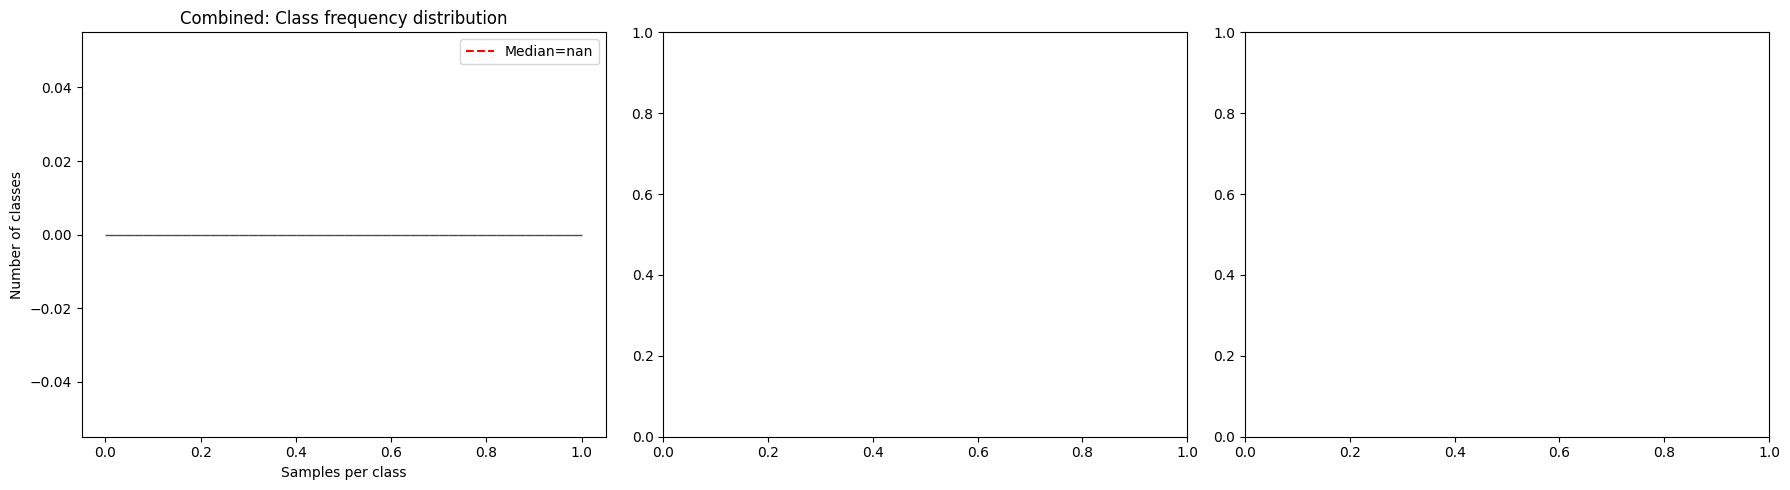

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Combined
axes[0].hist(class_counts.values, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Combined: Class frequency distribution")
axes[0].set_xlabel("Samples per class")
axes[0].set_ylabel("Number of classes")
axes[0].axvline(class_counts.median(), color="red", linestyle="--", label=f"Median={class_counts.median():.0f}")
axes[0].legend()

# Per source
for i, source_id in enumerate(df["source_id"].unique()):
    if i >= 2:
        break
    src_labels = df[df["source_id"] == source_id]["label"].fillna("").astype(str).str.strip()
    src_counts = src_labels[src_labels != ""].value_counts()
    axes[i+1].hist(src_counts.values, bins=50, edgecolor="black", alpha=0.7)
    axes[i+1].set_title(f"{source_id}: Class frequency distribution")
    axes[i+1].set_xlabel("Samples per class")
    axes[i+1].set_ylabel("Number of classes")
    axes[i+1].axvline(src_counts.median(), color="red", linestyle="--", label=f"Median={src_counts.median():.0f}")
    axes[i+1].legend()

plt.tight_layout()
plt.show()

## Log-scale histogram (long tail)

C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\478464272.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axvline(val, color=color, linestyle=style, label=f"Q{int(q*100)}={val:.0f}")


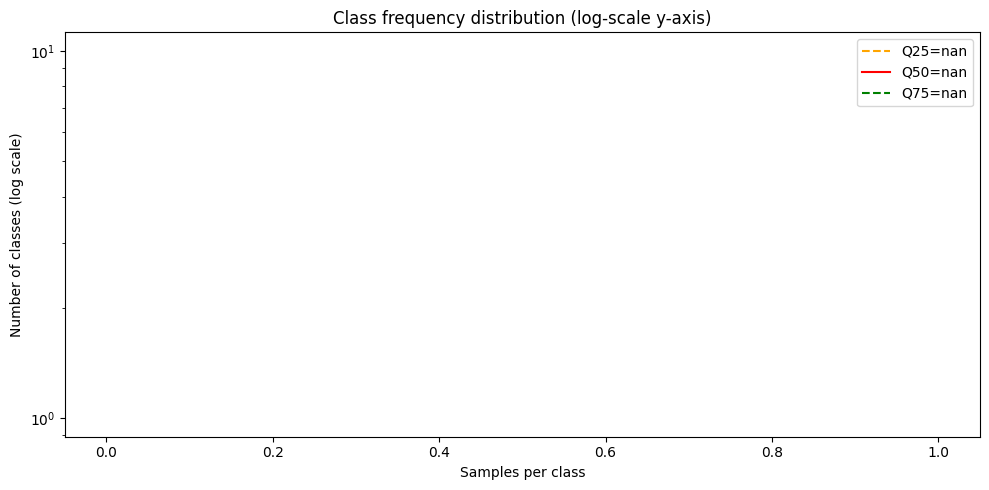

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(class_counts.values, bins=100, edgecolor="black", alpha=0.7, log=True)
ax.set_xlabel("Samples per class")
ax.set_ylabel("Number of classes (log scale)")
ax.set_title("Class frequency distribution (log-scale y-axis)")

for q, color, style in [(0.25, "orange", "--"), (0.5, "red", "-"), (0.75, "green", "--")]:
    val = class_counts.quantile(q)
    ax.axvline(val, color=color, linestyle=style, label=f"Q{int(q*100)}={val:.0f}")

ax.legend()
plt.tight_layout()
plt.show()

## Boxplots

C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\57532300.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(boxplot_data, labels=boxplot_labels, vert=True)
C:\Users\edlun\AppData\Local\Temp\ipykernel_21704\57532300.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(boxplot_data, labels=boxplot_labels, vert=True)


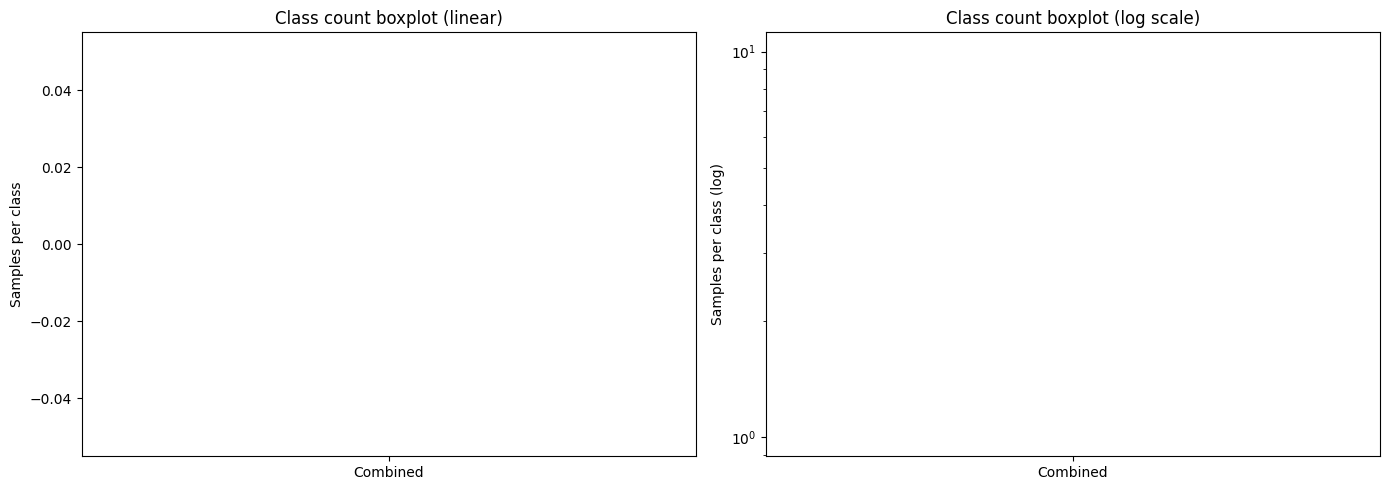

In [8]:
boxplot_data = [class_counts.values]
boxplot_labels = ["Combined"]

for source_id in df["source_id"].unique():
    src_labels = df[df["source_id"] == source_id]["label"].fillna("").astype(str).str.strip()
    src_counts = src_labels[src_labels != ""].value_counts()
    boxplot_data.append(src_counts.values)
    boxplot_labels.append(source_id)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].boxplot(boxplot_data, labels=boxplot_labels, vert=True)
axes[0].set_ylabel("Samples per class")
axes[0].set_title("Class count boxplot (linear)")

# Log scale
axes[1].boxplot(boxplot_data, labels=boxplot_labels, vert=True)
axes[1].set_yscale("log")
axes[1].set_ylabel("Samples per class (log)")
axes[1].set_title("Class count boxplot (log scale)")

plt.tight_layout()
plt.show()

## Rank-frequency plot (Zipf-style)

In [ ]:
sorted_counts = class_counts.sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(sorted_counts) + 1), sorted_counts)
axes[0].set_xlabel("Class rank")
axes[0].set_ylabel("Sample count")
axes[0].set_title("Rank-frequency plot (linear)")

axes[1].plot(range(1, len(sorted_counts) + 1), sorted_counts)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Class rank (log)")
axes[1].set_ylabel("Sample count (log)")
axes[1].set_title("Rank-frequency plot (log-log)")

plt.tight_layout()
plt.show()

## Cumulative coverage: what fraction of data do the top N classes cover?

In [ ]:
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative)
ax.set_xlabel("Number of classes (ranked by frequency)")
ax.set_ylabel("Cumulative fraction of total data")
ax.set_title("Cumulative class coverage")

for threshold in [0.5, 0.8, 0.9, 0.95]:
    idx = np.searchsorted(cumulative, threshold)
    ax.axhline(threshold, color="gray", linestyle=":", alpha=0.5)
    ax.axvline(idx + 1, color="gray", linestyle=":", alpha=0.5)
    ax.annotate(f"{threshold*100:.0f}% covered by {idx+1} classes",
                xy=(idx + 1, threshold), fontsize=8,
                xytext=(idx + len(cumulative)*0.05, threshold - 0.03))

plt.tight_layout()
plt.show()

## Summary table: top 20 and bottom 20 classes

In [ ]:
print("=== Top 20 most frequent classes ===")
print(class_counts.head(20).to_string())
print(f"\n=== Bottom 20 least frequent classes ===")
print(class_counts.tail(20).to_string())

## Imbalance ratio

In [ ]:
print(f"Max class count: {class_counts.max()} ({class_counts.idxmax()})")
print(f"Min class count: {class_counts.min()} ({class_counts.idxmin()})")
print(f"Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.0f}x")
print(f"Imbalance ratio (max/median): {class_counts.max() / class_counts.median():.1f}x")